## Upload two ZIP files:


In [1]:
import zipfile
import os

# ==============================
# ✅ Step 1: Give your zip file path
# ==============================
zip_path = r"C:\Users\UseR\Downloads\CoatNet Code\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia.zip"


In [2]:
# ==============================
# ✅ Step 2: Automatically create extraction folder
# ==============================
foldername = os.path.splitext(os.path.basename(zip_path))[0]  # extract filename without extension
foldername = foldername.replace(' ', '_').lower() + "_dataset"  # convert like your colab logic
extract_folder = os.path.join(os.path.dirname(zip_path), foldername)

In [3]:
# ==============================
# ✅ Step 3: Create folder if not exists
# ==============================
os.makedirs(extract_folder, exist_ok=True)


In [4]:
# ==============================
# ✅ Step 4: Extract the zip file
# ==============================
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"✅ Extracted '{zip_path}' to folder: {extract_folder}")


✅ Extracted 'C:\Users\UseR\Downloads\CoatNet Code\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia.zip' to folder: C:\Users\UseR\Downloads\CoatNet Code\chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset


In [5]:
# ==============================
# ✅ Step 5: Optional — verify files
# ==============================
import os

# Automatically list all *_dataset folders
dataset_folders = [d for d in os.listdir() if d.endswith('_dataset') and os.path.isdir(d)]

for folder in dataset_folders:
    print(f"\n📁 Inspecting: {folder}")
    for root, dirs, files in os.walk(folder):
        print("📂", root)
        for file in files[:5]:
            print("   └──", file)



📁 Inspecting: chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Testing
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Testing\normal
   └── normal-7688.jpg
   └── normal-7689.jpg
   └── normal-7690.jpg
   └── normal-7695.jpg
   └── normal-7696.jpg
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Testing\pneumonia
   └── pneumonia-5105.jpg
   └── pneumonia-5106.jpg
   └── pneumonia-5107.jpg
   └── pneumonia-5108.jpg
   └── pneumonia-5109.jpg
📂 chest-x-ray_epic_hospital_chittagong,_bangladesh_

✅ Classes: ['normal', 'pneumonia']
Training samples: 2113
Testing samples: 513


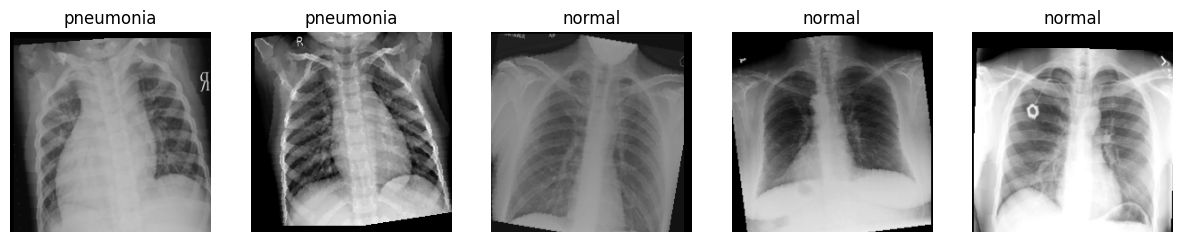

In [6]:
# ===============================
# Step 1: Import Libraries
# ===============================
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ===============================
# Step 2: Parameters
# ===============================
IMG_SIZE = 224
BATCH_SIZE = 16

# ===============================
# Step 3: Define Transforms
# ===============================
# Training: with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Testing: only resize + normalize
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# ===============================
# Step 4: Dataset Paths (use raw strings to avoid warning)
# ===============================
train_dir = r"chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Training"
test_dir  = r"chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Testing"

# ===============================
# Step 5: Load Datasets
# ===============================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

# ===============================
# Step 6: DataLoaders
# ===============================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ===============================
# Step 7: Verify Classes
# ===============================
class_names = train_dataset.classes
print("✅ Classes:", class_names)
print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

# ===============================
# Step 8: Visualize Augmented Images
# ===============================
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(15,3))

for i in range(5):
    img = images[i].permute(1, 2, 0).numpy()   # C,H,W → H,W,C
    img = (img * 0.5) + 0.5                    # unnormalize
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis("off")

plt.show()


# Visualize Sample Images

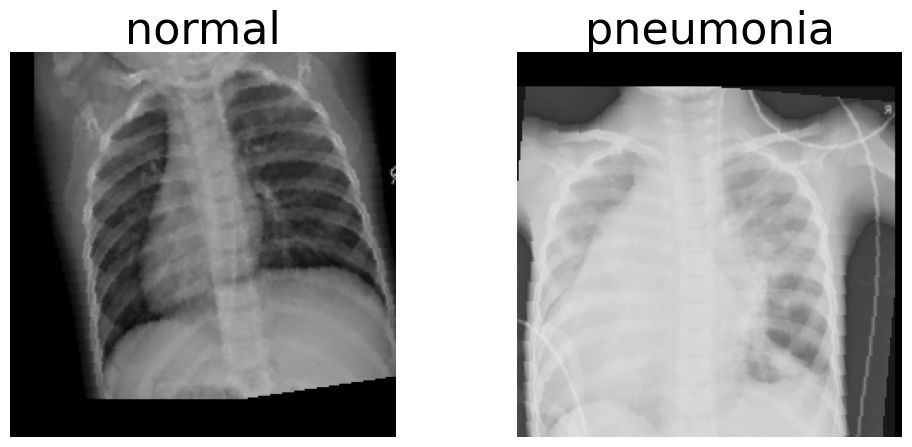

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    img = img * 0.5 + 0.5     # ✅ unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title, fontsize=32)
    plt.axis('off')

# Find the 2nd image per class
examples = {}
counts = {i: 0 for i in range(len(class_names))}

for img, label in train_dataset:
    if counts[label] == 41:   # pick the 42nd image (0-based)
        examples[label] = img
    counts[label] += 1
    if len(examples) == len(class_names):
        break

# Prepare images and titles sorted by label index
imgs = [examples[i] for i in range(len(class_names))]
titles = [class_names[i] for i in range(len(class_names))]

# Show images in one grid
plt.figure(figsize=(12, 5))
for i in range(len(class_names)):
    plt.subplot(1, len(class_names), i + 1)
    imshow(imgs[i], titles[i])
plt.show()



# ==== > 🔹 Final Setup for your Chest X-ray project <======
		===============================================================================

# Step 1: Model backbone: CoAtNet-0 (or CoAtNet-1/2 if GPU allows) **** [ Hybrid architecture(CoAtNet) = strong feature learning. ]

# Step 2 Training optimizer: SAM (instead of vanilla SGD/Adam) **** [ SAM optimizer = robustness + generalization. ]


# Step 3 Explainability: Grad-CAM (to visualize regions influencing predictions)
## [ Grad-CAM = interpretability (critical in medical imaging).]   


# 1--Install Dependencise ===> for Runing the Deep Learning Algo

In [ ]:
# Colab: install necessary libs
!pip install -q timm grad-cam scikit-learn

# 2---- Create transforms [ CoAtNet ]

## step 1 :  Picked CoAtNet-Nano and got its preprocessing config.
## step 2 : Created transform pipelines (train vs test).
## step 3 : Converted chest X-rays (grayscale) into 3-channel normalized tensors.
## step 4 : Built train/test dataloaders with proper augmentation and batching.
## 📌 This means your dataset is now ready to be fed into CoAtNet for training + evaluation.

In [9]:
# ====================================
# ✅ FIX: Disable HuggingFace symlink warning
# ====================================
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# ====================================
# 🔧 Install necessary libs (only once)
# ====================================
!pip install -q timm grad-cam scikit-learn

# ====================================
# 🚀 Imports & Setup
# ====================================
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm  # model zoo
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from sklearn.metrics import confusion_matrix, classification_report

# ====================================
# 🔒 Reproducibility
# ====================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# ====================================
# ⚡ Device setup (GPU or CPU)
# ====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ GPU device name:", torch.cuda.get_device_name(0))
    print("✅ Current device index:", torch.cuda.current_device())
else:
    print("❌ GPU not found. Using CPU.")

print("Device being used:", device)

# ====================================
# 🗂️ Dataset Paths
# ====================================
train_dir = r'chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Training'
test_dir  = r'chest-x-ray_epic_hospital_chittagong,_bangladesh_pneumonia_dataset\Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia\Testing'

IMG_SIZE = 224
BATCH_SIZE = 16

# ====================================
# 🧠 CoAtNet Model Data Config
# ====================================
model_name = 'coatnet_0_rw_224'

tmp_model = timm.create_model(model_name, pretrained=True, num_classes=1000)
data_config = timm.data.resolve_model_data_config(tmp_model)
print("Data config:", data_config)
del tmp_model

# ====================================
# 🧩 Transforms (grayscale → RGB)
# ====================================
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=data_config['mean'], std=data_config['std']),
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=data_config['mean'], std=data_config['std']),
])


CUDA available: True
✅ GPU device name: NVIDIA GeForce RTX 4070
✅ Current device index: 0
Device being used: cuda
Data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.95, 'crop_mode': 'center'}


## 🔍 Step 1: Confirm GPU availability in PyTorch

In [10]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("Current device index:", torch.cuda.current_device())


CUDA available: True
GPU device name: NVIDIA GeForce RTX 4070
Current device index: 0


In [11]:
# ========== Datasets & Dataloaders ==========
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Sizes: train", len(train_dataset), "test", len(test_dataset))


Classes: ['normal', 'pneumonia']
Sizes: train 2113 test 513


# 5 --📌 This step means: Our CoAtNet is now customized & ready for training on chest X-rays.
## Step 1 : Counted dataset classes → 3.
## Step 2 : Loaded CoAtNet-Nano pretrained on ImageNet.
## Step 3 : Replaced final classifier with a 3-class head.
## Step 4 : Sent model to GPU/CPU.
## Step 5 : Printed model to inspect layers for Grad-CAM.

In [12]:
# ========== Build CoAtNet model (timm) ==========
num_classes = len(class_names)
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model = model.to(device)
print(model)  # inspect to find reasonable target layer for Grad-CAM later (or use automated finder)


MaxxVit(
  (stem): Stem(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (norm1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  )
  (stages): Sequential(
    (0): MaxxVitStage(
      (blocks): Sequential(
        (0): MbConvBlock(
          (shortcut): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          )
          (pre_norm): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (down): Downsample2d(
            (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
            (expand): Identity

# 6--🔹 SAM optimizer implementation (lightweight)
## it makes oue training into two Steps
## step 1: Find sharp/worst-case weights (first_step).
## Step 2: Step back and update smoothly (second_step).

## 📌So now our training will use CoAtNet-Nano + SAM optimizer instead of plain Adam/SGD.

In [13]:
# =====================================================
# 1. Imports
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# =====================================================
# 2. SAM Optimizer Implementation
# =====================================================
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        # Base optimizer (AdamW in our case)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                if group['adaptive']:
                    e_w = (torch.abs(p) * p.grad) * scale
                else:
                    e_w = p.grad * scale
                p.add_(e_w)
                self.state[p]['e_w'] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def zero_grad(self):
        self.base_optimizer.zero_grad()

    def _grad_norm(self):
        device = self.param_groups[0]['params'][0].device
        norms = []
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                if group['adaptive']:
                    norms.append(((torch.abs(p) * p.grad).norm(2)).to(device))
                else:
                    norms.append((p.grad.norm(2)).to(device))
        if len(norms) == 0:
            return torch.tensor(0.).to(device)
        total_norm = torch.norm(torch.stack(norms), 2.0)
        return total_norm


# =====================================================
# 3. Hyperparameters & Setup
# =====================================================
num_epochs = 12
learning_rate = 1e-4
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# SAM + AdamW optimizer
base_optimizer = torch.optim.AdamW
optimizer = SAM(
    model.parameters(),
    base_optimizer,
    lr=learning_rate,
    weight_decay=weight_decay,
    rho=0.05,
    adaptive=False
)

# LR scheduler (on base optimizer inside SAM)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer.base_optimizer, step_size=7, gamma=0.1)


In [14]:
# =====================================================
# 4. Training & Evaluation Functions
# =====================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in tqdm(loader, desc="Train batches"):
        images, labels = images.to(device), labels.to(device)

        # Step 1
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # Step 2
        outputs2 = model(images)
        loss2 = criterion(outputs2, labels)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        running_loss += loss2.item() * images.size(0)
        preds = outputs2.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    return running_loss / total, correct / total, all_preds, all_labels

In [15]:
# =====================================================
# 5. Training Loop
# =====================================================
best_acc = 0.0
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, test_loader, criterion, device)

    scheduler.step()

    print(f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_coatnet_sam.pth")
        print("Saved best model.")


Epoch 1/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:32<00:00,  4.07it/s]


Train loss: 0.3761 acc: 0.8381 | Val loss: 0.1970 acc: 0.9240
Saved best model.

Epoch 2/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:28<00:00,  4.71it/s]


Train loss: 0.2532 acc: 0.9001 | Val loss: 0.2200 acc: 0.9240

Epoch 3/12


...

Train loss: 0.1593 acc: 0.9177 | Val loss: 0.1659 acc: 0.9201

Epoch 11/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:27<00:00,  4.81it/s]


Train loss: 0.1560 acc: 0.9186 | Val loss: 0.1718 acc: 0.9201

Epoch 12/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:27<00:00,  4.76it/s]


Train loss: 0.1528 acc: 0.9177 | Val loss: 0.1737 acc: 0.9201


In [16]:
# =====================================================
# 6. Final Evaluation
# =====================================================
model.load_state_dict(torch.load("best_coatnet_sam.pth", map_location=device))

_, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)

print("Test accuracy:", test_acc)
print(classification_report(labels, preds, target_names=class_names))
print("Confusion matrix:\n", confusion_matrix(labels, preds))

Test accuracy: 0.9259259259259259
              precision    recall  f1-score   support

      normal       1.00      0.86      0.92       257
   pneumonia       0.87      1.00      0.93       256

    accuracy                           0.93       513
   macro avg       0.93      0.93      0.93       513
weighted avg       0.93      0.93      0.93       513

Confusion matrix:
 [[220  37]
 [  1 255]]


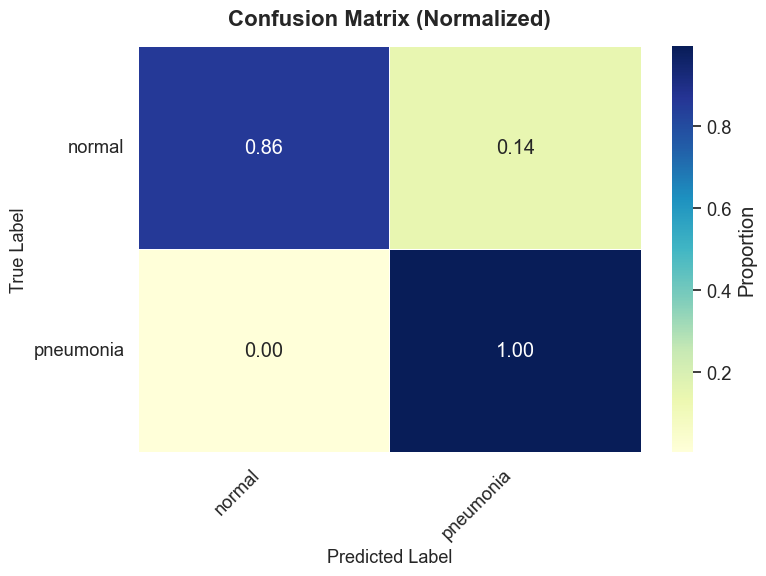

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(labels, preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize per class

# Plot
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.set_style("whitegrid")

ax = sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.7,
    cbar_kws={'label': 'Proportion'}
)

# Titles and labels
plt.title("Confusion Matrix (Normalized)", fontsize=16, weight='bold', pad=15)
plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Tight layout
plt.tight_layout()
plt.show()


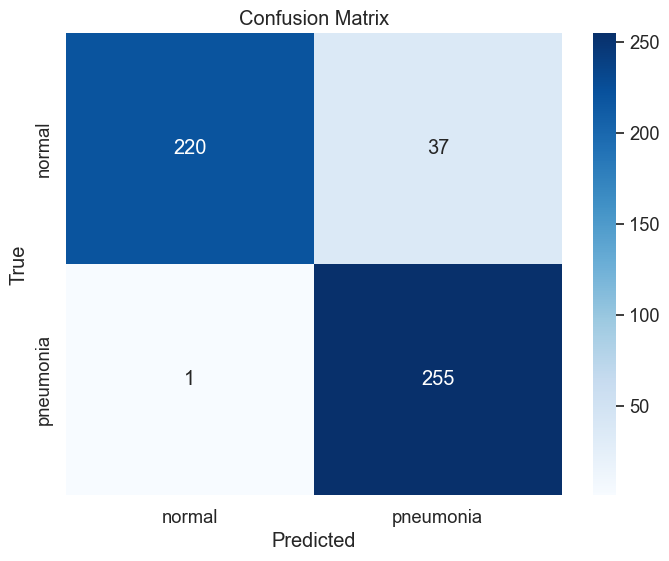

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")  # <- only the title, no accuracy
plt.show()


# 7---🔹 Train loop using SAM (two-step)
## step 1: First step = climb to sharp region (SAM perturbation).
## Step 2: Second step = update weights toward flat minimum (better generalization).
## Step 3 :Evaluate = check model performance without updating weights.
## Step 4 : Scheduler = adjust LR gradually.
## Step 5 : Checkpointing = keep the best model based on validation accuracy.
## 📌  This step sets up how your CoAtNet-Nano + SAM will learn during training.👉 Without SAM, this loop would only have one forward + one backward + optimizer.step() per batch.
## 👉 With SAM, you do two forwards + two backwards per batch (more expensive, but more robust)

Using target layer: stages.3.blocks.1.mlp.fc2


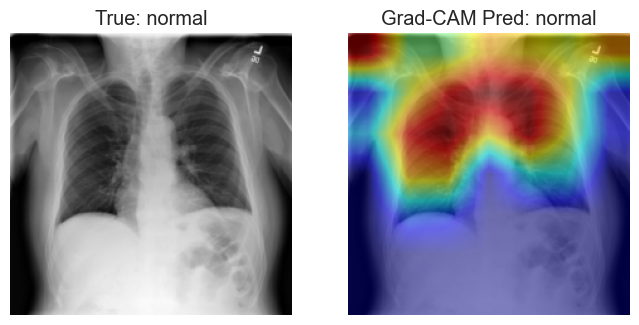

In [19]:
# =====================================================
# 7. Grad-CAM Visualization
# =====================================================
def unnormalize_tensor(img_tensor, mean, std):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    mean, std = np.array(mean), np.array(std)
    img = (img * std) + mean
    return np.clip(img, 0, 1)

def find_last_conv(model):
    last, last_name = None, None
    for n, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            last, last_name = m, n
    if last is None:
        raise ValueError("No Conv2d layer found.")
    print("Using target layer:", last_name)
    return last

target_layer = find_last_conv(model)

idx = 5  # pick a test sample
img_tensor, true_label = test_dataset[idx]
inp = img_tensor.unsqueeze(0).to(device)

cam = GradCAM(model=model, target_layers=[target_layer])

model.eval()
with torch.no_grad():
    out = model(inp)
pred_class = int(out.argmax(dim=1).cpu())

targets = [ClassifierOutputTarget(pred_class)]
grayscale_cam = cam(input_tensor=inp, targets=targets)
mask = grayscale_cam[0]

img_for_display = unnormalize_tensor(img_tensor, data_config['mean'], data_config['std'])
cam_image = show_cam_on_image(img_for_display, mask, use_rgb=True)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img_for_display); plt.title(f"True: {class_names[true_label]}"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cam_image); plt.title(f"Grad-CAM Pred: {class_names[pred_class]}"); plt.axis('off')
plt.show()

# 8.🔹 Training Loss & Validation Accuracy Plot


Epoch 1/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:28<00:00,  4.70it/s]


Train loss: 0.1896 acc: 0.9153 | Val loss: 0.1667 acc: 0.9181
Saved best model.

Epoch 2/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:27<00:00,  4.82it/s]


Train loss: 0.1765 acc: 0.9167 | Val loss: 0.1697 acc: 0.9201
Saved best model.

Epoch 3/12


...

Train loss: 0.1682 acc: 0.9177 | Val loss: 0.1707 acc: 0.9220

Epoch 11/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:27<00:00,  4.83it/s]


Train loss: 0.1664 acc: 0.9177 | Val loss: 0.1705 acc: 0.9181

Epoch 12/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:28<00:00,  4.67it/s]


Train loss: 0.1661 acc: 0.9172 | Val loss: 0.1718 acc: 0.9220


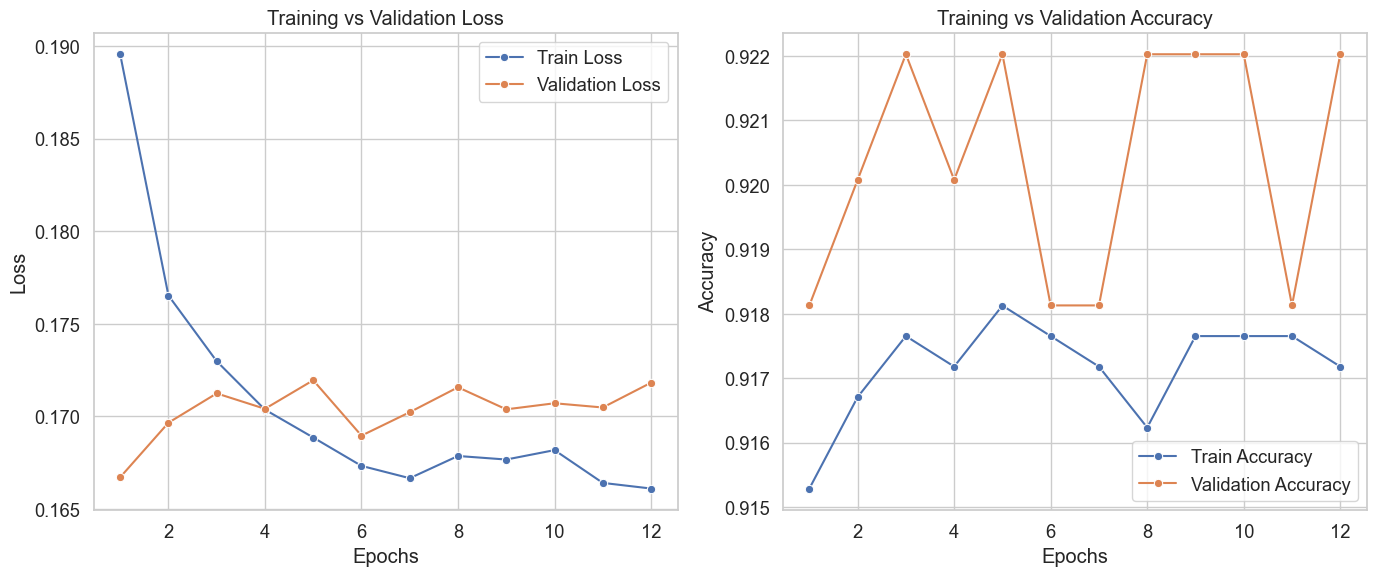

In [ ]:
# =====================================================
# 8. Training Loss & Validation Accuracy Plot
# =====================================================

# Store history during training
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_acc = 0.0
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, test_loader, criterion, device)

    scheduler.step()

    # save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_coatnet_sam.pth")
        print("Saved best model.")

# =====================================================
# 9. Plot Curves (with Seaborn)
# =====================================================
import seaborn as sns

# Apply seaborn style
sns.set(style="whitegrid", font_scale=1.2)

epochs = range(1, num_epochs+1)

plt.figure(figsize=(14,6))

# Plot Loss
plt.subplot(1,2,1)
sns.lineplot(x=epochs, y=train_losses, label='Train Loss', marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss', marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
sns.lineplot(x=epochs, y=train_accs, label='Train Accuracy', marker="o")
sns.lineplot(x=epochs, y=val_accs, label='Validation Accuracy', marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## More Good way using Seaborn

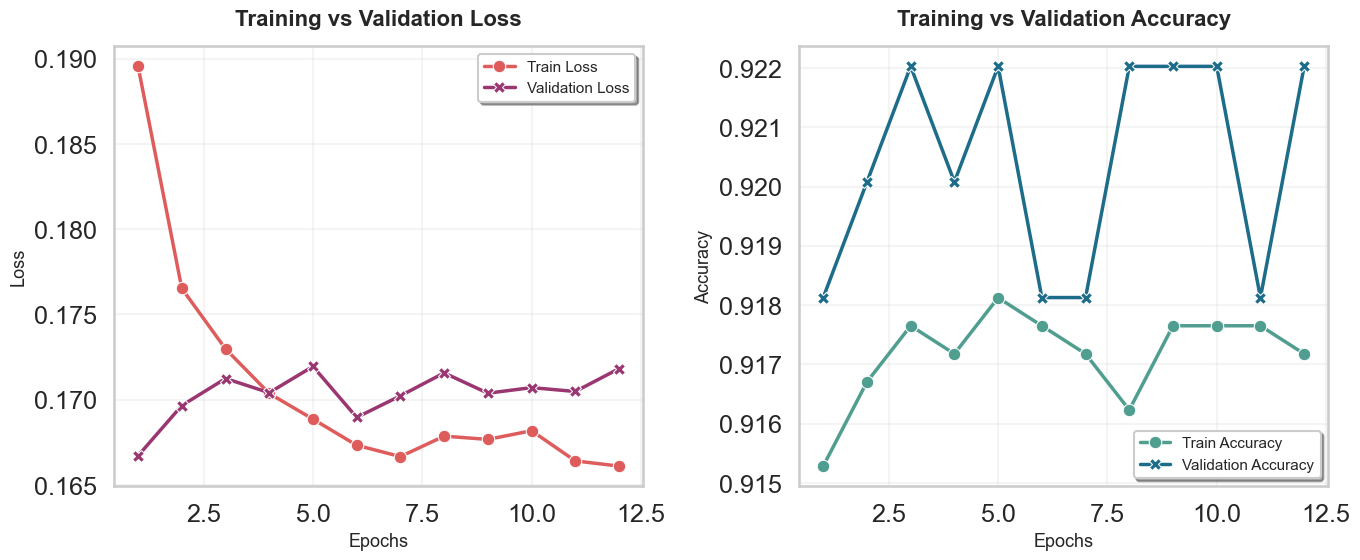

In [21]:
# =====================================================
# 🎨 Improved Seaborn Training & Validation Curve Plots
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for seaborn-friendly format
epochs = range(1, num_epochs + 1)
df = pd.DataFrame({
    'Epoch': list(epochs) * 4,
    'Value': train_losses + val_losses + train_accs + val_accs,
    'Metric': (['Train Loss'] * num_epochs) +
              (['Validation Loss'] * num_epochs) +
              (['Train Accuracy'] * num_epochs) +
              (['Validation Accuracy'] * num_epochs)
})

# Set seaborn theme
sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 🎯 Plot Loss
sns.lineplot(
    data=df[df['Metric'].isin(['Train Loss', 'Validation Loss'])],
    x='Epoch', y='Value', hue='Metric',
    style='Metric', markers=True, dashes=False,
    palette='flare', linewidth=2.5, ax=axes[0]
)
axes[0].set_title("Training vs Validation Loss", fontsize=16, weight='bold', pad=15)
axes[0].set_xlabel("Epochs", fontsize=13)
axes[0].set_ylabel("Loss", fontsize=13)
axes[0].legend(frameon=True, shadow=True, title='', fontsize=11)
axes[0].grid(alpha=0.2)

# 🎯 Plot Accuracy
sns.lineplot(
    data=df[df['Metric'].isin(['Train Accuracy', 'Validation Accuracy'])],
    x='Epoch', y='Value', hue='Metric',
    style='Metric', markers=True, dashes=False,
    palette='crest', linewidth=2.5, ax=axes[1]
)
axes[1].set_title("Training vs Validation Accuracy", fontsize=16, weight='bold', pad=15)
axes[1].set_xlabel("Epochs", fontsize=13)
axes[1].set_ylabel("Accuracy", fontsize=13)
axes[1].legend(frameon=True, shadow=True, title='', fontsize=11)
axes[1].grid(alpha=0.2)

# Adjust layout
plt.tight_layout()
plt.show()


# 9-🔹 Loss Curve Code for CoAtNet-0 + SAM + AdamW


In [ ]:
# =====================================================
# Track losses & accuracies
# =====================================================
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_acc = 0.0
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, test_loader, criterion, device)

    scheduler.step()

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_coatnet_sam.pth")
        print("Saved best model.")



Epoch 1/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:28<00:00,  4.75it/s]


Train loss: 0.1650 acc: 0.9177 | Val loss: 0.1708 acc: 0.9181
Saved best model.

Epoch 2/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:27<00:00,  4.83it/s]


Train loss: 0.1650 acc: 0.9177 | Val loss: 0.1698 acc: 0.9201
Saved best model.

Epoch 3/12


...

Train loss: 0.1659 acc: 0.9177 | Val loss: 0.1686 acc: 0.9181

Epoch 11/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:29<00:00,  4.44it/s]


Train loss: 0.1667 acc: 0.9177 | Val loss: 0.1699 acc: 0.9181

Epoch 12/12


Train batches: 100%|█████████████████████████████████████████████████████████████████| 133/133 [00:29<00:00,  4.52it/s]


Train loss: 0.1664 acc: 0.9177 | Val loss: 0.1732 acc: 0.9220


## We’ll see a clean loss curve (Train vs Validation) across epochs, which will help check:

## ==>  If train loss decreases smoothly (optimizer working well).

## ==>  If validation loss plateaus/diverges (signs of overfitting).

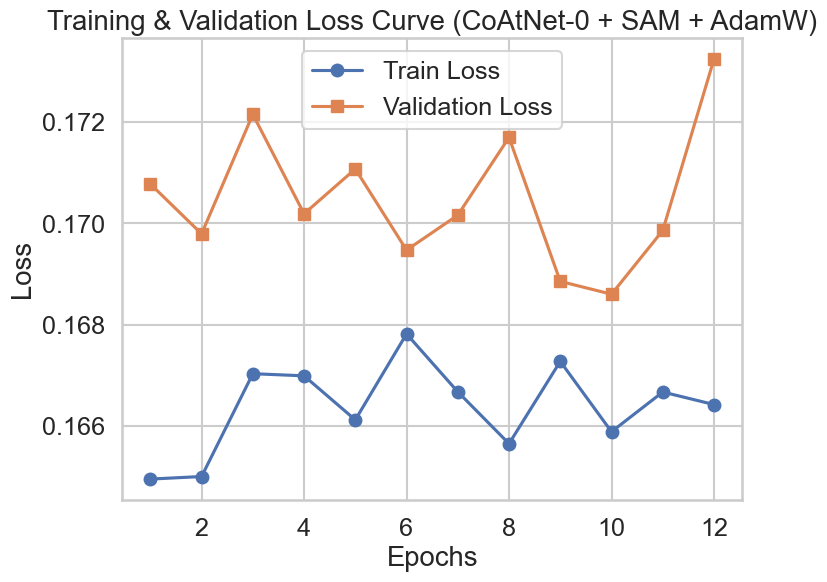

In [23]:
# =====================================================
# Plot Loss Curve
# =====================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve (CoAtNet-0 + SAM + AdamW)")
plt.legend()
plt.grid(True)
plt.show()
